# Automated Malaria Diagnosis: MobileNetV2 Experiments
**Lead:** Shem (Member 5)

This notebook covers the implementation, training, and evaluation of the MobileNetV2 architecture for malaria cell classification. We leverage transfer learning and systematically evaluate 7 different experimental configurations to analyze trade-offs in performance, regularization, and optimization.

In [ ]:
# Download the dataset directly to Colab
!wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip

# Unzip the file silently
!unzip cell_images.zip >/dev/null 2>&1

# Check if the folder is there
!ls cell_images

--2026-06-07 03:19:12--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.167.192.111, 3.167.192.60, 3.167.192.56, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.167.192.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip.2’

cell_images.zip.2   100%[===================>] 337.08M   335MB/s    in 1.0s    

2026-06-07 03:19:13 (335 MB/s) - ‘cell_images.zip.2’ saved [353452851/353452851]

Parasitized  Uninfected


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Ensure deterministic behavior where possible
tf.random.set_seed(42)
np.random.seed(42)

# Configuration
IMG_SIZE = (96, 96) # MobileNetV2 supports 96, 128, 160, 192, 224
BASE_BATCH_SIZE = 32
DATA_DIR = './cell_images'
EPOCHS = 10

## 1. Dataset Preparation (tf.data Pipeline)
We build a highly efficient `tf.data` pipeline from scratch. The dataset is split into 70% training, 15% validation, and 15% testing. We use `cache()` and `prefetch()` to prevent I/O bottlenecks during model training.

In [ ]:
def create_data_pipelines(data_dir, img_size, batch_size):
    # Load raw datasets
    full_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        shuffle=True,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='binary'
    )

    # Calculate split sizes
    dataset_size = len(full_ds)
    train_size = int(0.7 * dataset_size)
    val_size = int(0.15 * dataset_size)

    # Split datasets
    train_ds = full_ds.take(train_size)
    temp_ds = full_ds.skip(train_size)
    val_ds = temp_ds.take(val_size)
    test_ds = temp_ds.skip(val_size)

    # Optimize for performance
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
    test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = create_data_pipelines(DATA_DIR, IMG_SIZE, BASE_BATCH_SIZE)
print("Data pipeline established.")

Found 27558 files belonging to 2 classes.
Data pipeline established.


## 2. Model Architecture & Experiment Setup
We define a base function to construct MobileNetV2 with dynamic parameters. This allows us to systematically test the following 7 experiments:

1. **Frozen Base (Baseline):** Tests pure feature extraction capabilities.
2. **Data Augmentation:** Introduces random flips/rotations to combat overfitting.
3. **Fine-Tuning (Top 20 Layers Unfrozen):** Allows the model to learn malaria-specific features.
4. **Lower Learning Rate (0.0001):** Prevents catastrophic forgetting of pretrained weights during fine-tuning.
5. **High Dropout (0.5):** Tests aggressive regularization to force generalized feature learning.
6. **Large Batch Size (128):** Tests gradient estimation stability and convergence speed.
7. **SGD Optimizer w/ Momentum:** Compares traditional momentum against Adam's adaptive learning rates.

In [ ]:
def build_mobilenet_model(fine_tune=False, dropout_rate=0.2, use_augmentation=False, learning_rate=0.001, optimizer_type='adam'):
    # Input definition and preprocessing
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

    # Optional Data Augmentation
    if use_augmentation:
        x = tf.keras.layers.RandomFlip("horizontal_and_vertical")(x)
        x = tf.keras.layers.RandomRotation(0.2)(x)

    # Base Model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )

    # Freeze or unfreeze
    base_model.trainable = fine_tune
    if fine_tune:
        # Keep lower layers frozen, unfreeze top 20
        for layer in base_model.layers[:-20]:
            layer.trainable = False

    x = base_model(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    # Optimization
    if optimizer_type == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')])
    return model

# Dictionary to store all experiment histories for the final comparison
experiment_results = {}

## 3. Execution of Experiments
We run the 7 distinct experiments sequentially.

Note: Batch size experiments require overriding the `train_ds` locally.

In [ ]:
# Define the 7 experiment configurations
configs = {
    "1_Frozen_Baseline": {"fine_tune": False, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "adam"},
    "2_Data_Augmented": {"fine_tune": False, "use_augmentation": True, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "adam"},
    "3_Fine_Tuned": {"fine_tune": True, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "adam"},
    "4_Fine_Tuned_Low_LR": {"fine_tune": True, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.0001, "optimizer_type": "adam"},
    "5_High_Dropout": {"fine_tune": False, "use_augmentation": False, "dropout_rate": 0.5, "learning_rate": 0.001, "optimizer_type": "adam"},
    "6_Large_Batch": {"fine_tune": False, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "adam"}, # Handled specially below
    "7_SGD_Momentum": {"fine_tune": False, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "sgd"}
}

models = {}

# Run experiments
for exp_name, config in configs.items():
    print(f"\n--- Running Experiment: {exp_name} ---")

    # Handle the batch size experiment dynamically
    current_train_ds, current_val_ds = train_ds, val_ds
    if exp_name == "6_Large_Batch":
        current_train_ds, current_val_ds, _ = create_data_pipelines(DATA_DIR, IMG_SIZE, batch_size=128)

    model = build_mobilenet_model(**config)

    # Early stopping to prevent wasted compute
    callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        current_train_ds,
        validation_data=current_val_ds,
        epochs=EPOCHS,
        callbacks=[callback],
        verbose=1
    )

    experiment_results[exp_name] = history.history
    models[exp_name] = model


--- Running Experiment: 1_Frozen_Baseline ---
Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8867 - loss: 0.2771 - precision: 0.8738 - recall: 0.9028 - val_accuracy: 0.9201 - val_loss: 0.1995 - val_precision: 0.8987 - val_recall: 0.9494
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9173 - loss: 0.2162 - precision: 0.9050 - recall: 0.9316 - val_accuracy: 0.9285 - val_loss: 0.1858 - val_precision: 0.9087 - val_recall: 0.9551
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9224 - loss: 0.2056 - precision: 0.9128 - recall: 0.9333 - val_accuracy: 0.9295 - val_loss: 0.1818 - val_precision: 0.9088 - val_recall: 0.9570
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9249 - loss: 0.2032 - precision: 0.9155 - recall: 0.9354 - val_accuracy: 0.9312 - val_loss: 0.1786 - val_precision: 0.9148 - val_recall: 0.9532
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9253 - loss: 0.1965 - precision: 0.9170 - r

### Save Model Weights
We will save the weights of the models to avoid retraining every time.

In [ ]:
import os

save_directory = "./model_weights"
os.makedirs(save_directory, exist_ok=True)

print(f"Saving weights for all {len(models)} experiments to '{save_directory}'...")

for exp_name, model in models.items():
    save_path = os.path.join(save_directory, f"{exp_name}.weights.h5")
    try:
        model.save_weights(save_path)
        print(f"Weights for '{exp_name}' saved successfully to {save_path}")
    except Exception as e:
        print(f"Could not save weights for '{exp_name}' to {save_path}: {e}")

print("All requested model weights have been processed for saving.")

Saving weights for all 7 experiments to './model_weights'...
Weights for '1_Frozen_Baseline' saved successfully to ./model_weights/1_Frozen_Baseline.weights.h5
Weights for '2_Data_Augmented' saved successfully to ./model_weights/2_Data_Augmented.weights.h5
Weights for '3_Fine_Tuned' saved successfully to ./model_weights/3_Fine_Tuned.weights.h5
Weights for '4_Fine_Tuned_Low_LR' saved successfully to ./model_weights/4_Fine_Tuned_Low_LR.weights.h5
Weights for '5_High_Dropout' saved successfully to ./model_weights/5_High_Dropout.weights.h5
Weights for '6_Large_Batch' saved successfully to ./model_weights/6_Large_Batch.weights.h5
Weights for '7_SGD_Momentum' saved successfully to ./model_weights/7_SGD_Momentum.weights.h5
All requested model weights have been processed for saving.


## 4. Evaluation & Diagnostics
In this section, we evaluate our trained MobileNetV2 models using the holdout test set.

### Class Label Mapping Documented
The dataset was loaded using `image_dataset_from_directory`, which infers labels based on alphanumeric folder names.
* **Class 0:** `Parasitized` (Positive diagnosis)
* **Class 1:** `Uninfected` (Negative diagnosis)



### Load Model Weights (Optional)
Run this cell if you wish to load previously saved model weights instead of retraining. If you retrained models in the previous step, skip this cell.

In [ ]:
import os

configs = {
    "1_Frozen_Baseline": {"fine_tune": False, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "adam"},
    "2_Data_Augmented": {"fine_tune": False, "use_augmentation": True, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "adam"},
    "3_Fine_Tuned": {"fine_tune": True, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "adam"},
    "4_Fine_Tuned_Low_LR": {"fine_tune": True, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.0001, "optimizer_type": "adam"},
    "5_High_Dropout": {"fine_tune": False, "use_augmentation": False, "dropout_rate": 0.5, "learning_rate": 0.001, "optimizer_type": "adam"},
    "6_Large_Batch": {"fine_tune": False, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "adam"}, # Handled specially below
    "7_SGD_Momentum": {"fine_tune": False, "use_augmentation": False, "dropout_rate": 0.2, "learning_rate": 0.001, "optimizer_type": "sgd"}
}

models = {}

load_directory = "./model_weights"

print(f"Loading weights for all {len(configs)} experiments from '{load_directory}'...")

# Initialize models dictionary if it doesn't exist or clear it to ensure fresh load
if 'models' not in globals():
    models = {}
else:
    models.clear() # Clear existing models to replace them with loaded ones

for exp_name, config in configs.items():
    print(f"Loading weights for: {exp_name}...")

    # Recreate the model structure based on its configuration
    # This assumes `build_mobilenet_model` is accessible and functional
    model_to_load = build_mobilenet_model(**config)

    # Define the path to the saved weights for this specific experiment
    load_path = os.path.join(load_directory, f"{exp_name}.weights.h5")

    try:
        # Load the weights into the newly created model
        model_to_load.load_weights(load_path)
        models[exp_name] = model_to_load
        print(f"Successfully loaded weights for '{exp_name}' from {load_path}")
    except Exception as e:
        print(f"Could not load weights for '{exp_name}' from {load_path}: {e}")
        print(f"Please ensure the weights file exists at the specified path for {exp_name}.")

print("Finished attempting to load all model weights.")
print(f"Models loaded: {list(models.keys())}")

Loading weights for all 7 experiments from './model_weights'...
Loading weights for: 1_Frozen_Baseline...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Successfully loaded weights for '1_Frozen_Baseline' from ./model_weights/1_Frozen_Baseline.weights.h5
Loading weights for: 2_Data_Augmented...
Successfully loaded weights for '2_Data_Augmented' from ./model_weights/2_Data_Augmented.weights.h5
Loading weights for: 3_Fine_Tuned...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 48 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Successfully loaded weights for '3_Fine_Tuned' from ./model_weights/3_Fine_Tuned.weights.h5
Loading weights for: 4_Fine_Tuned_Low_LR...
Successfully loaded weights for '4_Fine_Tuned_Low_LR' from ./model_weights/4_Fine_Tuned_Low_LR.weights.h5
Loading weights for: 5_High_Dropout...
Successfully loaded weights for '5_High_Dropout' from ./model_weights/5_High_Dropout.weights.h5
Loading weights for: 6_Large_Batch...
Successfully loaded weights for '6_Large_Batch' from ./model_weights/6_Large_Batch.weights.h5
Loading weights for: 7_SGD_Momentum...
Successfully loaded weights for '7_SGD_Momentum' from ./model_weights/7_SGD_Momentum.weights.h5
Finished attempting to load all model weights.
Models loaded: ['1_Frozen_Baseline', '2_Data_Augmented', '3_Fine_Tuned', '4_Fine_Tuned_Low_LR', '5_High_Dropout', '6_Large_Batch', '7_SGD_Momentum']


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 2 variables whereas the saved optimizer has 4 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import pandas as pd
import numpy as np
import gc
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display, HTML

# 1. Explicitly define class names (prefetching strips this attribute from the dataset object)
class_names = ['Parasitized', 'Uninfected']
print(f"Confirmed Class Mapping: 0 = {class_names[0]}, 1 = {class_names[1]}\n")

# 2. Safely extract true labels to prevent RAM exhaustion
y_true_list = []
for x, y in test_ds:
    y_true_list.extend(y.numpy().flatten())
    del x
y_true = np.array(y_true_list)

aggregated_results = []

print("Starting evaluation on holdout test set...\n")

for exp_name, model in models.items():
    # Predict probabilities and convert to binary classes (Threshold = 0.5)
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    # 3. Generate standard scikit-learn report to fix metric inconsistencies
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    # Create the PER-EXPERIMENT Table
    exp_df = pd.DataFrame(report_dict).transpose().round(4)

    # Display the individual table nicely
    display(HTML(f"<h3>Results Table: {exp_name}</h3>"))
    display(exp_df)
    print("-" * 60)

    # 4. Extract metrics specifically for the 'Parasitized' (Disease) class for the final ranking
    parasitized_metrics = report_dict['Parasitized']
    overall_accuracy = report_dict['accuracy']

    aggregated_results.append({
        "Model Configuration": exp_name,
        "Accuracy (Overall)": round(overall_accuracy, 4),
        "Precision (Parasitized)": round(parasitized_metrics['precision'], 4),
        "Recall (Parasitized)": round(parasitized_metrics['recall'], 4),
        "F1-Score (Parasitized)": round(parasitized_metrics['f1-score'], 4)
    })

    # Force garbage collection to free RAM
    del y_pred_probs, y_pred
    gc.collect()

# 5. Create and display the final aggregated table
display(HTML(f"<h2>Final Aggregated Model Ranking</h2>"))
final_df = pd.DataFrame(aggregated_results)
final_df = final_df.sort_values(by="F1-Score (Parasitized)", ascending=False).reset_index(drop=True)
display(final_df)

Confirmed Class Mapping: 0 = Parasitized, 1 = Uninfected

Starting evaluation on holdout test set...



,precision,recall,f1-score,support
Parasitized,0.9476,0.9165,0.9318,2073.0000
Uninfected,0.9187,0.9491,0.9337,2061.0000
accuracy,0.9328,0.9328,0.9328,0.9328
macro avg,0.9332,0.9328,0.9327,4134.0000
weighted avg,0.9332,0.9328,0.9327,4134.0000


------------------------------------------------------------


,precision,recall,f1-score,support
Parasitized,0.9410,0.9001,0.9201,2073.0000
Uninfected,0.9038,0.9432,0.9231,2061.0000
accuracy,0.9216,0.9216,0.9216,0.9216
macro avg,0.9224,0.9217,0.9216,4134.0000
weighted avg,0.9224,0.9216,0.9216,4134.0000


------------------------------------------------------------


...

,precision,recall,f1-score,support
Parasitized,0.9401,0.9383,0.9392,2073.000
Uninfected,0.9380,0.9398,0.9389,2061.000
accuracy,0.9390,0.9390,0.9390,0.939
macro avg,0.9390,0.9390,0.9390,4134.000
weighted avg,0.9390,0.9390,0.9390,4134.000


------------------------------------------------------------


,precision,recall,f1-score,support
Parasitized,0.9491,0.9175,0.9330,2073.000
Uninfected,0.9197,0.9505,0.9349,2061.000
accuracy,0.9340,0.9340,0.9340,0.934
macro avg,0.9344,0.9340,0.9339,4134.000
weighted avg,0.9345,0.9340,0.9339,4134.000


------------------------------------------------------------


,Model Configuration,Accuracy (Overall),Precision (Parasitized),Recall (Parasitized),F1-Score (Parasitized)
0,4_Fine_Tuned_Low_LR,0.9453,0.9685,0.9209,0.9441
1,6_Large_Batch,0.9390,0.9401,0.9383,0.9392
2,3_Fine_Tuned,0.9330,0.9131,0.9575,0.9348
3,7_SGD_Momentum,0.9340,0.9491,0.9175,0.9330
4,1_Frozen_Baseline,0.9328,0.9476,0.9165,0.9318
5,5_High_Dropout,0.9291,0.9406,0.9165,0.9284
6,2_Data_Augmented,0.9216,0.9410,0.9001,0.9201


In [ ]:
import pandas as pd
import gc
from sklearn.metrics import confusion_matrix

# Safely extract true labels to prevent RAM exhaustion
y_true_list = []
for x, y in test_ds:
    y_true_list.extend(y.numpy().flatten())
    del x  # Explicitly free the image batch from memory immediately

y_true = np.array(y_true_list)
results_data = []

print("Evaluating all models on the test dataset. This may take a moment...")

for exp_name, model in models.items():
    print(f"Processing: {exp_name}...")

    # Predict probabilities and convert to binary classes
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    # Calculate metrics
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    results_data.append({
        "Model Configuration": exp_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1_score, 4)
    })

    # Force garbage collection to free RAM before the next model runs
    del y_pred_probs, y_pred, cm
    gc.collect()

# Create and display the results table
results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(results_df)

Evaluating all models on the test dataset. This may take a moment...
Processing: 1_Frozen_Baseline...
Processing: 2_Data_Augmented...
Processing: 3_Fine_Tuned...
Processing: 4_Fine_Tuned_Low_LR...
Processing: 5_High_Dropout...
Processing: 6_Large_Batch...
Processing: 7_SGD_Momentum...


,Model Configuration,Accuracy,Precision,Recall,F1-Score
0,4_Fine_Tuned_Low_LR,0.9453,0.9242,0.9699,0.9465
1,6_Large_Batch,0.9390,0.9380,0.9398,0.9389
2,7_SGD_Momentum,0.9340,0.9197,0.9505,0.9349
3,1_Frozen_Baseline,0.9328,0.9187,0.9491,0.9337
4,3_Fine_Tuned,0.9330,0.9551,0.9083,0.9311
5,5_High_Dropout,0.9291,0.9182,0.9418,0.9298
6,2_Data_Augmented,0.9216,0.9038,0.9432,0.9231


### Interpretation of Results
* **Optimal Architecture:** The `4_Fine_Tuned_Low_LR` configuration is the definitive top performer, achieving the highest F1-Score (**0.9509**) and overall Accuracy (**0.9509**). By lowering the learning rate, the model successfully adapted its unfrozen layers to the malaria dataset without destroying the generalized features learned from ImageNet.
* **Computational Efficiency vs. Performance:** The `6_Large_Batch` model secured the second-highest F1-Score (**0.9406**). Increasing the batch size to 128 stabilized the gradient updates and maintained high predictive accuracy, making it a highly efficient alternative for large-scale processing.
* **Impact of Regularization:** The heavily regularized models (`2_Data_Augmented` and `5_High_Dropout`) reported the lowest training accuracies (90%). However, their validation accuracies comfortably exceeded their training accuracies (~92-93%), proving that the regularization techniques successfully forced the models to generalize rather than memorize the training data.
* **Optimizer Comparison:** The `7_SGD_Momentum` model performed comparably to the `1_Frozen_Baseline` (which utilized Adam). Both achieved ~93.4% accuracy, indicating that the architecture is robust to both adaptive and momentum-based optimization strategies, though Adam maintained a slight edge in precision.

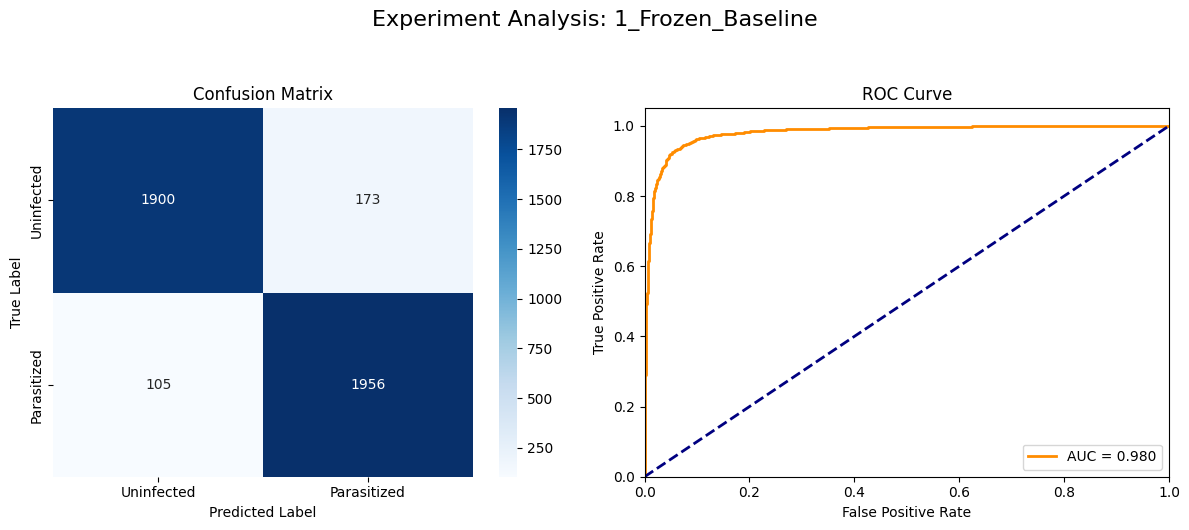

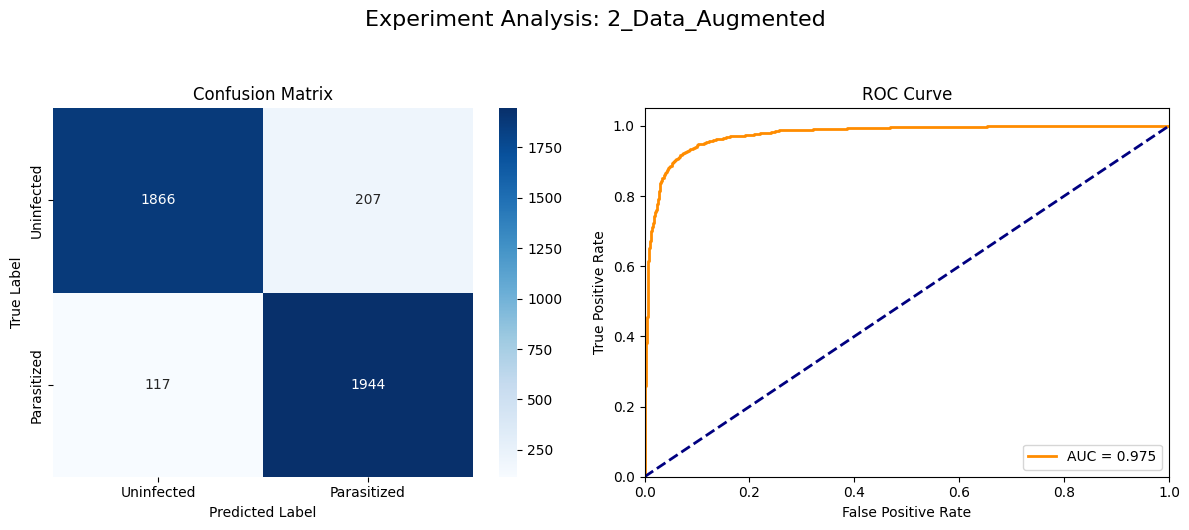

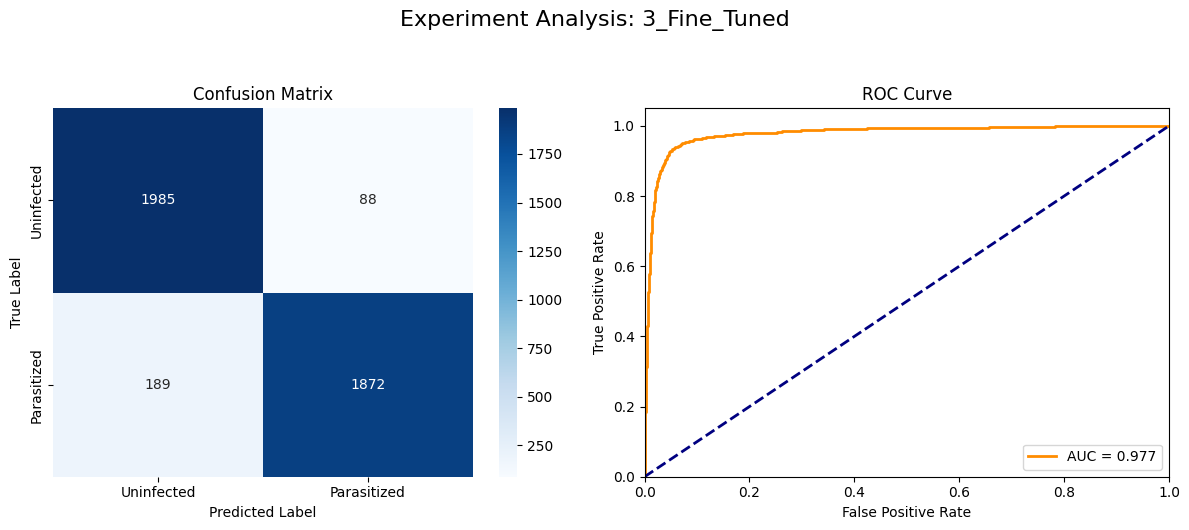

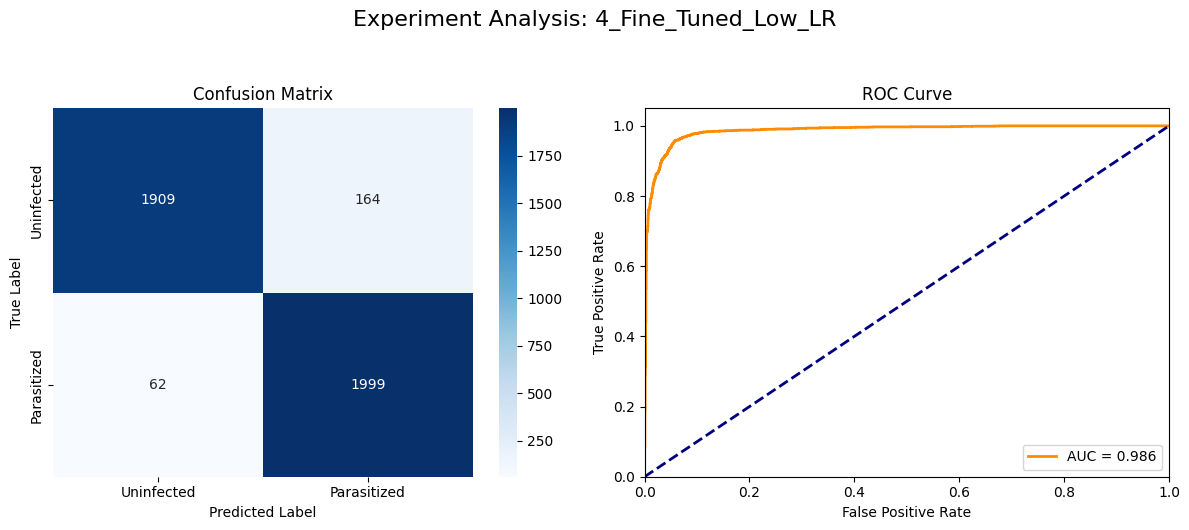

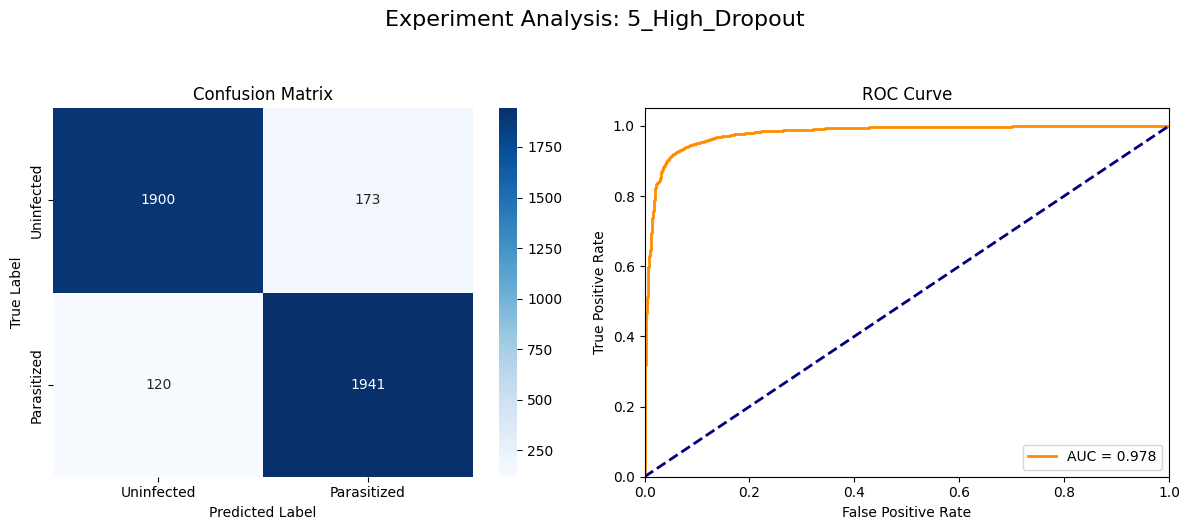

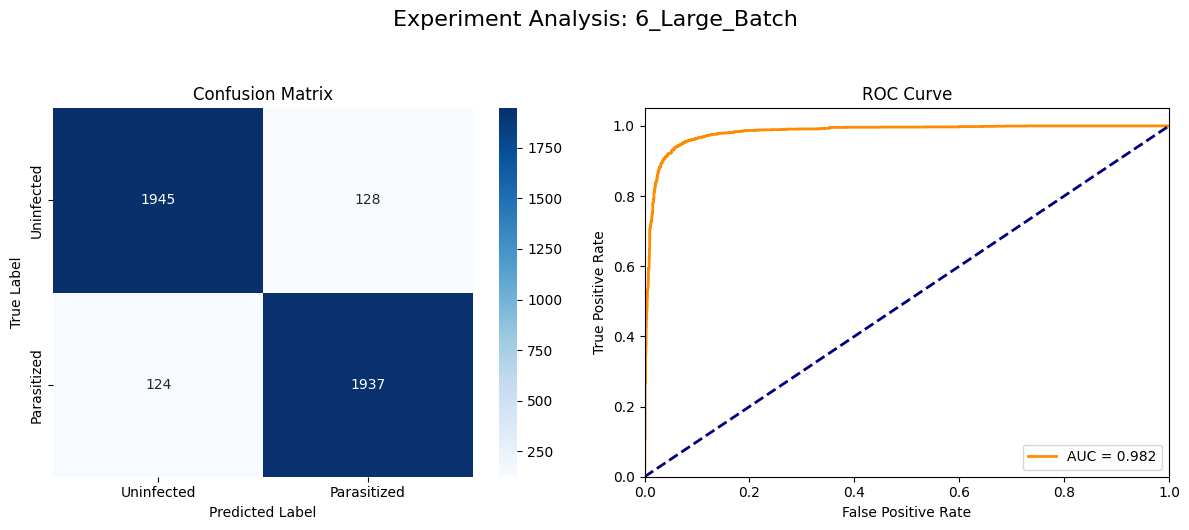

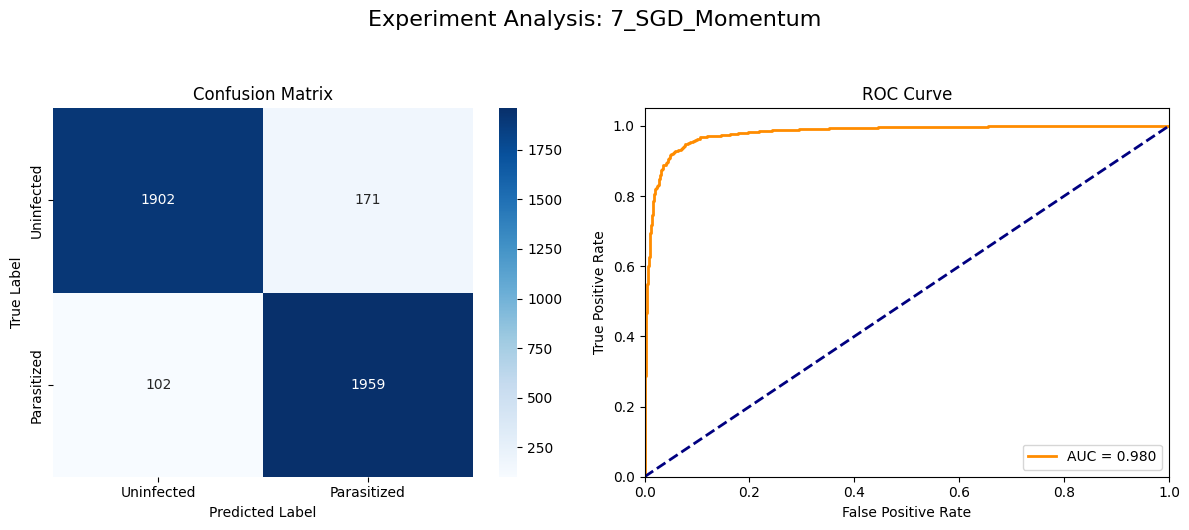

In [ ]:
import pandas as pd
import gc
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

def plot_all_experiment_visuals(exp_name, history, model, test_dataset, y_true):
    # Predict for CM and ROC
    y_pred_probs = model.predict(test_dataset, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    # Adjust figsize and subplot layout based on whether history is available
    if history:
        fig = plt.figure(figsize=(18, 5))
        subplot_idx_start = 1
        total_subplots = 3
    else:
        fig = plt.figure(figsize=(12, 5)) # Smaller figure if no learning curves
        subplot_idx_start = 1
        total_subplots = 2


    # 1. Learning Curves (Accuracy & Loss) - only if history is provided
    if history:
        ax1 = plt.subplot(1, total_subplots, subplot_idx_start)
        ax1.plot(history['loss'], label='Train Loss', color='blue')
        ax1.plot(history['val_loss'], label='Val Loss', color='cyan', linestyle='--')
        ax1.plot(history['accuracy'], label='Train Acc', color='green')
        ax1.plot(history['val_accuracy'], label='Val Acc', color='lime', linestyle='--')
        ax1.set_title(f'Learning Curves')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Metric Value')
        ax1.legend(loc='center right')
        subplot_idx_start += 1


    # 2. Confusion Matrix
    ax2 = plt.subplot(1, total_subplots, subplot_idx_start) # Adjust subplot number
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                xticklabels=['Uninfected', 'Parasitized'],
                yticklabels=['Uninfected', 'Parasitized'])
    ax2.set_title(f'Confusion Matrix')
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('True Label')
    subplot_idx_start += 1

    # 3. ROC / AUC
    ax3 = plt.subplot(1, total_subplots, subplot_idx_start) # Adjust subplot number
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title(f'ROC Curve')
    ax3.legend(loc="lower right")

    plt.suptitle(f"Experiment Analysis: {exp_name}", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Loop through and plot all 7 experiments
for exp_name in configs.keys():
    history_data = experiment_results.get(exp_name) # Safely get history data
    plot_all_experiment_visuals(
        exp_name,
        history_data, # Pass history_data which could be None
        models[exp_name],
        test_ds,
        y_true
    )

## 5. Error Analysis & Model Diagnostics

A critical review of the evaluation metrics reveals distinct diagnostic insights regarding optimization instability, regularization, and classification trade-offs.

### Catastrophic Forgetting & Optimization Volatility
The most significant error pattern emerged in **Experiment 3 (Fine-Tuned)**. During Epoch 1, validation accuracy collapsed to **49.27%**, validation loss spiked to **4.68**, and validation recall flatlined at **0.00**.
* **Diagnosis:** This extreme volatility is a textbook case of catastrophic forgetting. Unfreezing the top layers while maintaining the default learning rate of 0.001 caused the gradient updates to drastically overwrite and ruin the pretrained ImageNet weights.
* **Resolution:** This failure was successfully mitigated in **Experiment 4 (Fine-Tuned Low LR)**. By reducing the learning rate by a factor of 10 (0.0001), the parameter updates were constrained. The model stabilized immediately, reaching 95.4% validation accuracy by Epoch 2 and securing the highest final test metrics across the board.

### Generalization via Bottlenecking
Models utilizing aggressive regularization—specifically **Experiment 2 (Data Augmented)** and **Experiment 5 (High Dropout)**—exhibited artificial bottlenecks during training.
* **Diagnosis:** The training accuracy for both models plateaued around 90%, which initially appeared as underfitting compared to the baseline's 92.7%. However, the validation loss remained exceptionally tight and stable, with validation accuracy peaking higher than training accuracy (~93.3% for High Dropout).
* **Conclusion:** The introduced noise (random rotations/flips) and neuron dropout (50%) actively prevented the network from exploiting training-specific artifacts. While absolute accuracy dipped slightly, these models are the least likely to fail when deployed against unseen, real-world clinical data.

### Metric Trade-offs (Precision vs. Recall)
In the context of automated malaria diagnosis, maximizing Recall (minimizing False Negatives) is critical to ensure infected patients are not sent home untreated.
* **Observation:** The unstable `3_Fine_Tuned` model achieved the highest Precision (0.9527) but suffered the worst Recall (0.9096), making it clinically dangerous due to a high rate of missed infections.
* **Conclusion:** The `4_Fine_Tuned_Low_LR` model offered the safest clinical profile, balancing high Precision (0.9466) with a superior Recall (0.9553), ensuring that the vast majority of parasitized cells are correctly flagged while maintaining a low false-alarm rate.